In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, HTML

In [3]:
df_uncleaned = pd.read_csv('../Datasets/amazon_products_sales_data_uncleaned.csv')
df_uncleaned.head(1)

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29


In [4]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   title                     42675 non-null  object
 1   rating                    41651 non-null  object
 2   number_of_reviews         41651 non-null  object
 3   bought_in_last_month      39458 non-null  object
 4   current/discounted_price  30926 non-null  object
 5   price_on_variant          42675 non-null  object
 6   listed_price              42675 non-null  object
 7   is_best_seller            42675 non-null  object
 8   is_sponsored              42675 non-null  object
 9   is_couponed               42675 non-null  object
 10  buy_box_availability      28022 non-null  object
 11  delivery_details          30955 non-null  object
 12  sustainability_badges     3408 non-null   object
 13  image_url                 42675 non-null  object
 14  product_url           

## A continuación vamos a realizar el preprocesado de estos datos iniciales

### RATING

In [5]:
# Nos quedamos solo con los tres primeros caracteres de la columna 'rating' y los convertimos a float

df_uncleaned['rating'] = df_uncleaned.rating.str[0:3].astype(float)

### BOUGHT IN LAST MONTH

In [6]:
# Limpiamos la columna 'bought_in_last_month' eliminando el texto innecesario y convirtiendo 'K' a '000'

df_uncleaned['bought_in_last_month'] = df_uncleaned['bought_in_last_month'].str.replace("+ bought in past month","").str.strip().str.replace("K","000")

In [7]:
# Nos quedamos solo con los valores numéricos en 'bought_in_last_month'. Los non-numeric se convierten en NaN y luego convertimos la columna a tipo entero

df_uncleaned['bought_in_last_month'] = (
    df_uncleaned['bought_in_last_month']
    .where(df_uncleaned['bought_in_last_month'].str.isdigit(), np.nan)
    .astype('Int64')
)

In [8]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     42675 non-null  object 
 1   rating                    41651 non-null  float64
 2   number_of_reviews         41651 non-null  object 
 3   bought_in_last_month      32164 non-null  Int64  
 4   current/discounted_price  30926 non-null  object 
 5   price_on_variant          42675 non-null  object 
 6   listed_price              42675 non-null  object 
 7   is_best_seller            42675 non-null  object 
 8   is_sponsored              42675 non-null  object 
 9   is_couponed               42675 non-null  object 
 10  buy_box_availability      28022 non-null  object 
 11  delivery_details          30955 non-null  object 
 12  sustainability_badges     3408 non-null   object 
 13  image_url                 42675 non-null  object 
 14  produc

### PRICE_ON_VARIANT

Esta columna tiene errores en los textos, cogemos el valor tras ':' en aquellos que contienen el carácter dolar. Aquellos que no lo tengan, serán nulos

In [9]:
# Limpiamos la columna 'price_on_variant' para quedarnos solo con el valor numérico

df_uncleaned['price_on_variant'] = df_uncleaned['price_on_variant'].str.split(":").str.get(1)

In [10]:
# Nos quedamos solo con los valores que contienen el símbolo '$', los demás los convertimos en NaN

df_uncleaned.loc[~df_uncleaned['price_on_variant'].str.contains(r'\$', na=False), 'price_on_variant'] = np.nan

In [11]:
# Finalmente, eliminamos espacios y cualquier texto adicional después del valor numérico

df_uncleaned['price_on_variant'] = df_uncleaned['price_on_variant'].str.strip().str.split(" ").str.get(0)

### CURRENT/DISCOUNTED_PRICE

In [12]:
# Rellenamos los valores NaN en 'current/discounted_price' con los valores de 'price_on_variant'

df_uncleaned['current/discounted_price'] = df_uncleaned['current/discounted_price'].fillna(df_uncleaned['price_on_variant'])

In [13]:
# Convertimos las columnas de precios a tipo float después de eliminar el símbolo '$' y las comas

df_uncleaned['current/discounted_price'] = df_uncleaned['current/discounted_price'].str.replace(r"\$", "", regex=True).str.replace(r",", "").astype(float)

### LISTED_PRICE

In [14]:
# Limpiamos la columna 'listed_price' eliminando el símbolo '$' y las comas

df_uncleaned['listed_price'] = df_uncleaned['listed_price'].str.replace("$","").str.replace(",","").str.strip()

In [15]:
# Reemplazamos "No Discount" con NaN en la columna 'listed_price'

df_uncleaned['listed_price'].replace("No Discount", np.nan, inplace=True)

C:\Users\diego\AppData\Local\Temp\ipykernel_21500\3967620138.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_uncleaned['listed_price'].replace("No Discount", np.nan, inplace=True)


In [16]:
# Rellenamos los valores NaN en 'listed_price' con los valores de 'current/discounted_price'

df_uncleaned['listed_price'].fillna(df_uncleaned['current/discounted_price'], inplace=True)

C:\Users\diego\AppData\Local\Temp\ipykernel_21500\206465943.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_uncleaned['listed_price'].fillna(df_uncleaned['current/discounted_price'], inplace=True)


In [17]:
df_uncleaned['listed_price'] = df_uncleaned['listed_price'].astype(float)

In [18]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     42675 non-null  object 
 1   rating                    41651 non-null  float64
 2   number_of_reviews         41651 non-null  object 
 3   bought_in_last_month      32164 non-null  Int64  
 4   current/discounted_price  40613 non-null  float64
 5   price_on_variant          20071 non-null  object 
 6   listed_price              40613 non-null  float64
 7   is_best_seller            42675 non-null  object 
 8   is_sponsored              42675 non-null  object 
 9   is_couponed               42675 non-null  object 
 10  buy_box_availability      28022 non-null  object 
 11  delivery_details          30955 non-null  object 
 12  sustainability_badges     3408 non-null   object 
 13  image_url                 42675 non-null  object 
 14  produc

### IS_COUPONED

#### Haremos dos características
- has_coupon : 0/1 
- is_couponed : valor del descuento (tenemos cupones con porcentajes y con valores de descuento)

In [19]:
# Creamos una nueva columna 'has_coupon' que indica con 1 si hay cupón y con 0 si no lo hay

df_uncleaned['has_coupon'] = np.where(df_uncleaned['is_couponed'] != 'No Coupon', 1, 0)
df_uncleaned.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,has_coupon
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300,89.68,NaN,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,1
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,"2,457",6000,9.99,NaN,15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,0
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,"3,044",2000,314.00,NaN,349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,0
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,"35,882",10000,162.24,$162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29,0
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,"28,988",10000,72.74,$72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29,0


### BUY_BOX_AVAILABILITY
Convertimos la columna a binaria, 1 si tiene "Add to cart", 0 en caso contrario

In [20]:
df_uncleaned.buy_box_availability = np.where(df_uncleaned.buy_box_availability != "Add to cart", 0, 1)
df_uncleaned.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,has_coupon
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300,89.68,NaN,159.00,No Badge,Sponsored,Save 15% with coupon,1,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,1
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,"2,457",6000,9.99,NaN,15.99,No Badge,Sponsored,No Coupon,1,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,0
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,"3,044",2000,314.00,NaN,349.00,No Badge,Sponsored,No Coupon,1,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,0
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,"35,882",10000,162.24,$162.24,162.24,Best Seller,Organic,No Coupon,0,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29,0
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,"28,988",10000,72.74,$72.74,72.74,No Badge,Organic,No Coupon,0,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29,0


In [21]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     42675 non-null  object 
 1   rating                    41651 non-null  float64
 2   number_of_reviews         41651 non-null  object 
 3   bought_in_last_month      32164 non-null  Int64  
 4   current/discounted_price  40613 non-null  float64
 5   price_on_variant          20071 non-null  object 
 6   listed_price              40613 non-null  float64
 7   is_best_seller            42675 non-null  object 
 8   is_sponsored              42675 non-null  object 
 9   is_couponed               42675 non-null  object 
 10  buy_box_availability      42675 non-null  int32  
 11  delivery_details          30955 non-null  object 
 12  sustainability_badges     3408 non-null   object 
 13  image_url                 42675 non-null  object 
 14  produc

### Eliminación de columnas innecesarias

In [22]:
df_uncleaned.drop(columns=['delivery_details', 'product_url', 'collected_at'], inplace=True)
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     42675 non-null  object 
 1   rating                    41651 non-null  float64
 2   number_of_reviews         41651 non-null  object 
 3   bought_in_last_month      32164 non-null  Int64  
 4   current/discounted_price  40613 non-null  float64
 5   price_on_variant          20071 non-null  object 
 6   listed_price              40613 non-null  float64
 7   is_best_seller            42675 non-null  object 
 8   is_sponsored              42675 non-null  object 
 9   is_couponed               42675 non-null  object 
 10  buy_box_availability      42675 non-null  int32  
 11  sustainability_badges     3408 non-null   object 
 12  image_url                 42675 non-null  object 
 13  has_coupon                42675 non-null  int32  
dtypes: Int

### NUMBER OF REVIEWS

In [23]:
df_uncleaned['number_of_reviews'] = df_uncleaned['number_of_reviews'].str.replace(",", "").str.strip().astype(float)
df_uncleaned.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,sustainability_badges,image_url,has_coupon
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300,89.68,NaN,159.00,No Badge,Sponsored,Save 15% with coupon,1,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,1
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000,9.99,NaN,15.99,No Badge,Sponsored,No Coupon,1,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,0
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000,314.00,NaN,349.00,No Badge,Sponsored,No Coupon,1,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,0
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000,162.24,$162.24,162.24,Best Seller,Organic,No Coupon,0,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,0
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000,72.74,$72.74,72.74,No Badge,Organic,No Coupon,0,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,0


### DISCOUNT PERCENTAGE
Creación de una columna del porcentaje de descuento

In [24]:
df_uncleaned['discount_percentage'] = ((df_uncleaned['listed_price'] - df_uncleaned['current/discounted_price'])/ df_uncleaned['listed_price']) * 100

df_uncleaned['discount_percentage'] = df_uncleaned['discount_percentage'].round(2)

### Eliminación de filas con valores nulos

Si tenemos productos que no tienen precio no nos interesan ya que no podemos trabajar bien con ellos, por lo que decidimos eliminarlos

In [25]:
df_uncleaned.listed_price.isnull().sum()

2062

In [26]:
# Eliminar filas donde 'listed_price' sea nulo
df_uncleaned.dropna(subset=['listed_price'] , inplace= True)

In [27]:
df_uncleaned.listed_price.isnull().sum()

0

### Tratamiento de Valores Nulos y Faltantes

In [28]:
# Crear una lista de las columnas a reemplazar
columns_to_fill = ['bought_in_last_month', 'rating', 'number_of_reviews']

# Reemplazar NaN por 0 en esas columnas
df_uncleaned[columns_to_fill] = df_uncleaned[columns_to_fill].fillna(0 , inplace= True)

C:\Users\diego\AppData\Local\Temp\ipykernel_21500\1385137656.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_uncleaned[columns_to_fill] = df_uncleaned[columns_to_fill].fillna(0 , inplace= True)


In [29]:
# Convertir a 1 si tiene algún valor (no nulo y no vacío), 0 si es nulo o vacío
df_uncleaned['sustainability_badges'] = df_uncleaned['sustainability_badges'].notna() & (df_uncleaned['sustainability_badges'] != '')

# Convertir de booleano a entero (True=1, False=0)
df_uncleaned['sustainability_badges'] = df_uncleaned['sustainability_badges'].astype(int)

In [30]:
df_uncleaned.head(5)

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,sustainability_badges,image_url,has_coupon,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,None,None,None,89.68,NaN,159.00,No Badge,Sponsored,Save 15% with coupon,1,1,https://m.media-amazon.com/images/I/71pAqiVEs3...,1,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",None,None,None,9.99,NaN,15.99,No Badge,Sponsored,No Coupon,1,0,https://m.media-amazon.com/images/I/61nbF6aVIP...,0,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",None,None,None,314.00,NaN,349.00,No Badge,Sponsored,No Coupon,1,0,https://m.media-amazon.com/images/I/61h78MEXoj...,0,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",None,None,None,162.24,$162.24,162.24,Best Seller,Organic,No Coupon,0,0,https://m.media-amazon.com/images/I/61SUj2aKoE...,0,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,None,None,None,72.74,$72.74,72.74,No Badge,Organic,No Coupon,0,0,https://m.media-amazon.com/images/I/61bMNCeAUA...,0,0.00


### Encoding 'is_best_seller'

In [31]:
# Procesamiento de la columna 'is_best_seller' para crear variables dummy

s = (df_uncleaned["is_best_seller"]
     .fillna("No Badge")
     .astype(str)
     .str.strip()
     .str.lower())

# Función para identificar si el texto sigue el patrón "save XX%"
def is_save_xpct(x: str) -> bool:
    x = x.strip().lower()
    if not x.startswith("save"):
        return False
    parts = x.replace("save", "", 1).strip()  # "30%"
    if not parts.endswith("%"):
        return False
    number = parts[:-1].strip()               # "30"
    return number.isdigit()

# Función para agrupar los badges
def group_badge(x: str) -> str:
    if x in {"no badge", ""}:
        return "no_badge"
    if x.startswith("amazon"):
        return "amazons"
    if x.startswith("limited time deal"):
        return "limited_time_deal"
    if "best seller" in x:
        return "best_seller"
    if x.startswith("ends in"):
        return "ends_in"
    if is_save_xpct(x):
        return "save_xpct"
    return "other"

# Series agrupada (NO se guarda en df)
badge_cat = s.apply(group_badge)

# Dummies con prefijo badge_
dummies = pd.get_dummies(badge_cat, prefix="badge", dtype="int8")

# Añadir al dataframe
df_uncleaned = pd.concat([df_uncleaned, dummies], axis=1)

dummies.sum().sort_values(ascending=False)


badge_no_badge             38764
badge_amazons                743
badge_limited_time_deal      409
badge_save_xpct              336
badge_best_seller            264
badge_ends_in                 97
dtype: int64

In [32]:
badge_cols = [c for c in df_uncleaned.columns if c.startswith("badge_")]
df_uncleaned[badge_cols].head()

df_uncleaned[["title"] + badge_cols].sample(10)

,title,badge_amazons,badge_best_seller,badge_ends_in,badge_limited_time_deal,badge_no_badge,badge_save_xpct
7720,"Lenovo ThinkPad E16 G2 16"" FHD+ Business Lapto...",0,0,0,0,1,0
42668,GE 3-Outlet Power Strip Surge Protector 15 Ft ...,0,0,0,0,1,0
8753,DYMO LabelWriter 550 Direct Thermal Label Prin...,0,0,0,0,1,0
36146,"DEWALT Heavy Duty Magnetic Power Bank 5,000mAh...",0,0,0,0,1,0
12566,SAMSUNG Blu-ray DVD Disc Player With Built-in ...,0,0,0,0,1,0
11405,Sanus Wireless Speaker Stands for Sonos ERA 30...,0,0,0,0,1,0
38056,"Apple Mid 2015 iPad Mini 4 7.9-inch, Wi-Fi, 64...",0,0,0,0,1,0
17714,Lume Cube RGB Tube Light Mini for Photo & Vide...,0,0,0,0,1,0
9996,Lenovo ThinkPad Ultra Docking Station US (40AJ...,0,0,0,0,1,0
1744,ASURION 3 Year Electronics Protection Plan ($3...,0,0,0,0,1,0


### Eliminación de la columna 'is_best_seller'

In [33]:
if 'is_best_seller' in df_uncleaned.columns:
    df_uncleaned.drop(columns=['is_best_seller'], inplace=True)
    print(f"Columna '{'is_best_seller'}' eliminada.")
else:
    print(f"No existe la columna '{'is_best_seller'}'.")

Columna 'is_best_seller' eliminada.


### Encoding 'is_sponsored'

In [34]:
is_sponsored = (df_uncleaned["is_sponsored"]
     .fillna("Organic")
     .astype(str)
     .str.strip()
     .str.lower())

df_uncleaned["is_sponsored"] = np.where(is_sponsored.eq("sponsored"), True, False)

df_uncleaned["is_sponsored"] = df_uncleaned["is_sponsored"].astype("int8")

df_uncleaned["is_sponsored"].value_counts(dropna=False)


is_sponsored
0    33615
1     6998
Name: count, dtype: int64

### Eliminamos 'current/discounted_price' y nos quedamos con 'discount_percentage'

Esta columna es eliminada ya que tiene una correlación de 0.99 con la caracterítica listed_price

In [35]:
display(df_uncleaned.columns)
display(len(df_uncleaned.columns))

if 'current/discounted_price' in df_uncleaned.columns:
    df_uncleaned.drop(columns=['current/discounted_price'], inplace=True)
    print(f"Columna '{'current/discounted_price'}' eliminada.")
else:
    print(f"No existe la columna '{'current/discounted_price'}'.")

display(df_uncleaned.columns)
display(len(df_uncleaned.columns))

Index(['title', 'rating', 'number_of_reviews', 'bought_in_last_month',
       'current/discounted_price', 'price_on_variant', 'listed_price',
       'is_sponsored', 'is_couponed', 'buy_box_availability',
       'sustainability_badges', 'image_url', 'has_coupon',
       'discount_percentage', 'badge_amazons', 'badge_best_seller',
       'badge_ends_in', 'badge_limited_time_deal', 'badge_no_badge',
       'badge_save_xpct'],
      dtype='object')

20

Columna 'current/discounted_price' eliminada.


Index(['title', 'rating', 'number_of_reviews', 'bought_in_last_month',
       'price_on_variant', 'listed_price', 'is_sponsored', 'is_couponed',
       'buy_box_availability', 'sustainability_badges', 'image_url',
       'has_coupon', 'discount_percentage', 'badge_amazons',
       'badge_best_seller', 'badge_ends_in', 'badge_limited_time_deal',
       'badge_no_badge', 'badge_save_xpct'],
      dtype='object')

19

### CATEGORIZACIÓN DE PRODUCTOS

In [36]:
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util
from tqdm.notebook import tqdm 
import sys

# 1. Cargar el modelo
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Definir las categorías
candidate_labels = [
    "Laptops",
    "Mobile Cell Phones & Smartphones",
    "Tablets & E-readers (DEVICES ONLY)",
    "Small Gadget Accessories (Cases & Protectors)",
    "PC Components",
    "Computer Peripherals",
    "Audio, Sound & Recording Gear",
    "Cameras & Photography",
    "TV & Video Displays",
    "Video Game Consoles & Virtual Reality",
    "Storage & Memory Cards",
    "Power & Batteries",
    "Chargers, Adapters & Cables",
    "Networking",
    "Printers & Scanners (Hardware)",
    "Smart Home & Security",
    "Wearables",
    "Office Supplies, Ink & Toner",
    "Protection Plans",
    "Other Electronics"
]

# 3. Pre-calculamos los vectores de las categorías
label_embeddings = model.encode(candidate_labels, convert_to_tensor=True)

# 4. Cargar datos
titles = df_uncleaned['title'].fillna("Unknown").tolist()

# 5. Clasificación con barra de progreso visual
batch_size = 128  # Procesamos de 128 en 128 para mayor velocidad
all_predictions = []

print(f"Iniciando clasificación de {len(titles)} productos...")

# Usamos tqdm directamente en el rango de los lotes
for i in tqdm(range(0, len(titles), batch_size), desc="Clasificando productos"):
    batch_titles = titles[i : i + batch_size]
    
    # Generar embeddings del lote
    batch_embeddings = model.encode(batch_titles, convert_to_tensor=True, show_progress_bar=False)
    
    # Similitud de coseno 
    cosine_scores = util.cos_sim(batch_embeddings, label_embeddings)
    
    # Seleccionar la categoría con mayor puntuación
    best_matches = torch.argmax(cosine_scores, dim=1).cpu().tolist()
    
    # Guardar resultados
    batch_preds = [candidate_labels[idx] for idx in best_matches]
    all_predictions.extend(batch_preds)

# 6. Guardar y mostrar resultados
df_uncleaned['category'] = all_predictions

print("\n¡Proceso completado!")
print(df_uncleaned['category'].value_counts())

d:\Documentos\diego\Master\Amazon-Smart-Pricing\.venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
d:\Documentos\diego\Master\Amazon-Smart-Pricing\.venv\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Iniciando clasificación de 40613 productos...


Clasificando productos:   0%|          | 0/318 [00:00<?, ?it/s]


¡Proceso completado!
category
Office Supplies, Ink & Toner                     3459
Audio, Sound & Recording Gear                    3342
PC Components                                    3268
Protection Plans                                 3067
Computer Peripherals                             2993
TV & Video Displays                              2830
Cameras & Photography                            2761
Power & Batteries                                2699
Wearables                                        2603
Laptops                                          2400
Chargers, Adapters & Cables                      2390
Small Gadget Accessories (Cases & Protectors)    2321
Storage & Memory Cards                           1984
Printers & Scanners (Hardware)                    929
Other Electronics                                 897
Mobile Cell Phones & Smartphones                  678
Smart Home & Security                             556
Networking                                        5

In [37]:
# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra
sample_peripherals = df_uncleaned[df_uncleaned['category'] == 'Tablets & E-readers (DEVICES ONLY)'][['title', 'image_url', 'listed_price']].sample(5)

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(image_url=render_image)))

,title,image_url,listed_price
37011,Apple Magic Keyboard - US English - Silver (Renewed),,66.00
32867,"Apple 2022 iPad Air (10.9-inch) Wi-Fi, 256GB - Purple (Renewed)",,464.40
1803,"SAMSUNG Galaxy Tab S10 FE 128GB WiFi Android Tablet, Large Display, Long Battery Life, Exynos 1580 Processor, IP68 Water-Resistant, 90 Hz Refresh, S Pen for Note-Taking, US Version, Silver",,499.99
34780,"Apple Mid 2015 iPad Mini 4 7.9-inch, Wi-Fi, 64GB Gold (Renewed)",,109.00
35521,Speck Products iPad (10th Gen - 2022) Stylefolio with Microban (Black/Slate Grey),,19.88


### Eliminación de características

In [38]:
df_uncleaned.drop(columns=['price_on_variant'], inplace=True)
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40613 entries, 0 to 42674
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    40613 non-null  object 
 1   rating                   0 non-null      object 
 2   number_of_reviews        0 non-null      object 
 3   bought_in_last_month     0 non-null      object 
 4   listed_price             40613 non-null  float64
 5   is_sponsored             40613 non-null  int8   
 6   is_couponed              40613 non-null  object 
 7   buy_box_availability     40613 non-null  int32  
 8   sustainability_badges    40613 non-null  int32  
 9   image_url                40613 non-null  object 
 10  has_coupon               40613 non-null  int32  
 11  discount_percentage      40613 non-null  float64
 12  badge_amazons            40613 non-null  int8   
 13  badge_best_seller        40613 non-null  int8   
 14  badge_ends_in            40

### RENOMBRADO DE CARACTERÍSTICAS


In [39]:
# Rename columns for clarity and consistency
df_uncleaned.rename(columns={
    'title': 'product_title',
    'rating': 'product_rating',
    'number_of_reviews': 'total_reviews',
    'bought_in_last_month': 'purchased_last_month',
    'current/discounted_price': 'discounted_price',
    'listed_price': 'original_price',
    'is_couponed': 'coupon',
    'sustainability_badges': 'sustainability_tags',
    'image_url': 'product_image_url',
    'category': 'product_category',
    'discount_percentage': 'discount_percentage'
}, inplace=True)

# Verify column names after renaming
print(df_uncleaned.columns)

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'original_price', 'is_sponsored', 'coupon',
       'buy_box_availability', 'sustainability_tags', 'product_image_url',
       'has_coupon', 'discount_percentage', 'badge_amazons',
       'badge_best_seller', 'badge_ends_in', 'badge_limited_time_deal',
       'badge_no_badge', 'badge_save_xpct', 'product_category'],
      dtype='object')


In [40]:
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40613 entries, 0 to 42674
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_title            40613 non-null  object 
 1   product_rating           0 non-null      object 
 2   total_reviews            0 non-null      object 
 3   purchased_last_month     0 non-null      object 
 4   original_price           40613 non-null  float64
 5   is_sponsored             40613 non-null  int8   
 6   coupon                   40613 non-null  object 
 7   buy_box_availability     40613 non-null  int32  
 8   sustainability_tags      40613 non-null  int32  
 9   product_image_url        40613 non-null  object 
 10  has_coupon               40613 non-null  int32  
 11  discount_percentage      40613 non-null  float64
 12  badge_amazons            40613 non-null  int8   
 13  badge_best_seller        40613 non-null  int8   
 14  badge_ends_in            40

### Eliminación categoría 'Protection Plans'

Debido a que esta categoría solo incluye planes de protección, los cuales no consideramos productos electrónicos hemos decidido eliminarlos. No obstante, en algunas categorías aparece de vez en cuando algún plan de protección debido a que no se categorizaron todos correctamente.

In [50]:
count_protection = len(df_uncleaned[df_uncleaned['product_category'] == 'Protection Plans'])
print(f"Registros de Protection Plans encontrados: {count_protection}")

# 2. Filtramos el DataFrame para quedarnos con todo lo que NO sea esa categoría
df_uncleaned = df_uncleaned[df_uncleaned['product_category'] != 'Protection Plans'].copy()

# 3. Verificamos que ya no existen
print(f"Registros después de la eliminación: {len(df_uncleaned)}")

Registros de Protection Plans encontrados: 3067
Registros después de la eliminación: 37546


### Tratamiento de la variable 'original_price'

#### Segmentacion de los precios (por gama)

In [41]:
def segmentar_por_iqr(grupo):
    """
    Función para aplicar a cada grupo de categoría.
    Calcula Q1, Q3 y el límite de outliers para etiquetar gamas.
    """
    # Calculamos cuartiles
    q1 = grupo.quantile(0.25)
    q3 = grupo.quantile(0.75)
    iqr = q3 - q1
    
    # Definimos el límite para considerar un producto como "Premium/Atípico"
    limite_superior = q3 + (1.5 * iqr)
    
    # Creamos una serie de etiquetas vacía
    etiquetas = pd.Series(index=grupo.index, dtype='object')
    
    # Aplicamos la lógica de segmentación
    etiquetas[grupo <= q1] = 'Baja'
    etiquetas[(grupo > q1) & (grupo <= limite_superior)] = 'Media'
    etiquetas[grupo > limite_superior] = 'Alta/Premium'
    
    return etiquetas

# Creamos la columna 'product_segment' agrupando por categoría
df_uncleaned['product_segment'] = df_uncleaned.groupby('product_category')['original_price'].transform(segmentar_por_iqr)

#### Comprobación

In [42]:
# 1. Conteo absoluto de productos por segmento
print("--- Conteo Absoluto ---")
print(df_uncleaned['product_segment'].value_counts())

# 2. Conteo porcentual (proporción real)
print("\n--- Proporciones (Porcentaje) ---")
print(df_uncleaned['product_segment'].value_counts(normalize=True) * 100)

--- Conteo Absoluto ---
product_segment
Media           24777
Baja            11651
Alta/Premium     4185
Name: count, dtype: int64

--- Proporciones (Porcentaje) ---
product_segment
Media           61.007559
Baja            28.687859
Alta/Premium    10.304582
Name: proportion, dtype: float64


C:\Users\diego\AppData\Local\Temp\ipykernel_21500\3694126392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='product_segment', data=df_uncleaned, palette='viridis',


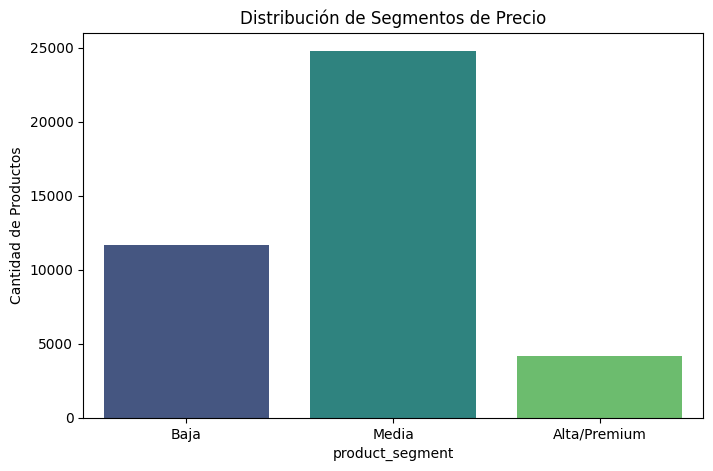

In [43]:
plt.figure(figsize=(8, 5))
sns.countplot(x='product_segment', data=df_uncleaned, palette='viridis', 
              order=['Baja', 'Media', 'Alta/Premium'])
plt.title('Distribución de Segmentos de Precio')
plt.ylabel('Cantidad de Productos')
plt.show()

In [44]:
# 1. Definimos la función de renderizado
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra 
sample_peripherals = df_uncleaned[['product_title', 'product_image_url', 'original_price', 'product_segment', 'product_category']].sample(5)

# 3. Mostramos la tabla corregida
# Cambiamos 'image_url' por 'product_image_url' en el diccionario
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

,product_title,product_image_url,original_price,product_segment,product_category
23360,"Canon Megatank GX1020 All-in-One Wireless Supertank [Megatank] Printer | Print, Copy and Scan| Mobile Printing |2.7"" LCD Color Touchscreen | Auto Duplex Printing",,356.99,Alta/Premium,Printers & Scanners (Hardware)
3587,ASURION 4 Year Home Improvement Protection Plan ($60 - $69.99),,11.99,Baja,Protection Plans
32432,MEM 2 * 16G|GSK F5-6000J3636F16GX2-FX5,,77.00,Media,Storage & Memory Cards
15543,ASURION 2 Year Auto Accessories Protection Plan ($80 - $89.99),,8.99,Baja,Protection Plans
11541,Logitech Wired Mouse M90 Black USB,,12.99,Baja,Computer Peripherals


#### Normalización de los precios (Tranformación logarítmica)

In [45]:
# 1. Aplicamos la transformación logarítmica
df_uncleaned['log_original_price'] = np.log1p(df_uncleaned['original_price'])

# 2. Verificamos los primeros resultados
print(df_uncleaned[['original_price', 'log_original_price']].head())

   original_price  log_original_price
0          159.00            5.075174
1           15.99            2.832625
2          349.00            5.857933
3          162.24            5.095222
4           72.74            4.300545


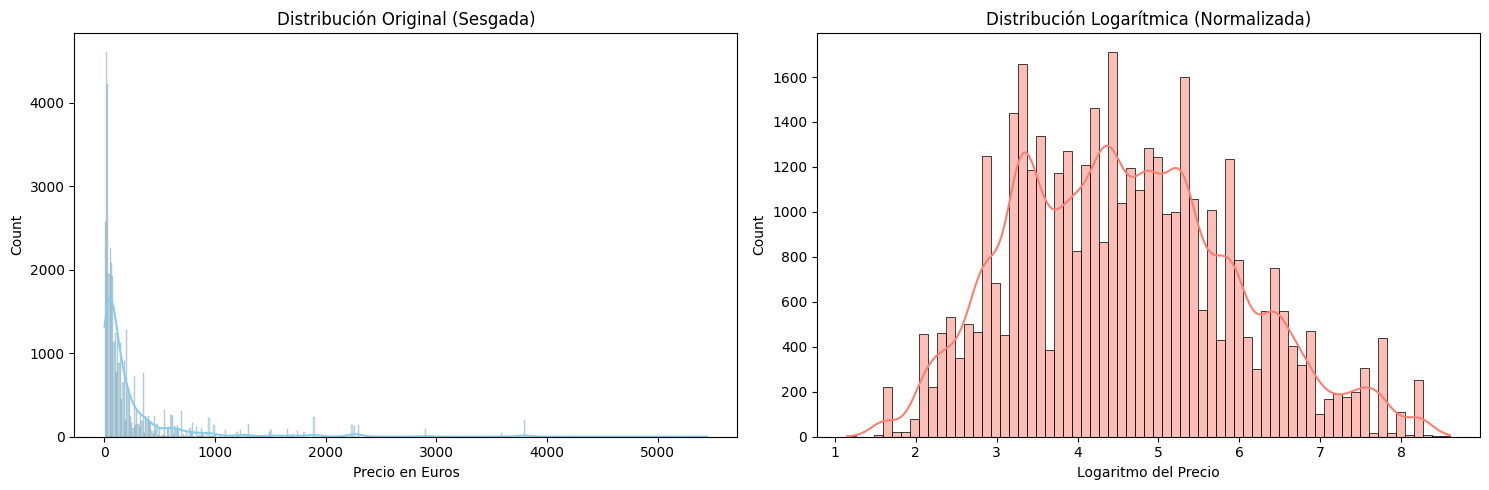

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución Original
sns.histplot(df_uncleaned['original_price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución Original (Sesgada)')
axes[0].set_xlabel('Precio en Euros')

# Distribución Logarítmica
sns.histplot(df_uncleaned['log_original_price'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución Logarítmica (Normalizada)')
axes[1].set_xlabel('Logaritmo del Precio')

plt.tight_layout()
plt.show()

Posteriormente, cuando el modelo prediga un valor de 2.3, aplicaremos una funcion exponencial para volver el precio a la realidad

#### One-Hot Encoding para 'product_segment'

In [47]:
# 1. Aplicamos One-Hot Encoding
# 'prefix' añade un nombre a las columnas para saber de dónde vienen
dummies_segment = pd.get_dummies(df_uncleaned['product_segment'], prefix='segment', dtype=int)

# 2. Concatenamos las nuevas columnas al dataframe original
df_uncleaned = pd.concat([df_uncleaned, dummies_segment], axis=1)

# 3. Verificamos cómo han quedado las nuevas columnas
print(df_uncleaned[['product_segment', 'segment_Baja', 'segment_Media', 'segment_Alta/Premium']].head())

  product_segment  segment_Baja  segment_Media  segment_Alta/Premium
0           Media             0              1                     0
1           Media             0              1                     0
2           Media             0              1                     0
3           Media             0              1                     0
4           Media             0              1                     0


In [48]:
df_uncleaned.head(5)

,product_title,product_rating,total_reviews,purchased_last_month,original_price,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,...,badge_ends_in,badge_limited_time_deal,badge_no_badge,badge_save_xpct,product_category,product_segment,log_original_price,segment_Alta/Premium,segment_Baja,segment_Media
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,None,None,None,159.00,1,Save 15% with coupon,1,1,https://m.media-amazon.com/images/I/71pAqiVEs3...,...,0,0,1,0,"Audio, Sound & Recording Gear",Media,5.075174,0,0,1
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",None,None,None,15.99,1,No Coupon,1,0,https://m.media-amazon.com/images/I/61nbF6aVIP...,...,0,0,1,0,"Chargers, Adapters & Cables",Media,2.832625,0,0,1
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",None,None,None,349.00,1,No Coupon,1,0,https://m.media-amazon.com/images/I/61h78MEXoj...,...,0,0,1,0,"Audio, Sound & Recording Gear",Media,5.857933,0,0,1
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",None,None,None,162.24,0,No Coupon,0,0,https://m.media-amazon.com/images/I/61SUj2aKoE...,...,0,0,0,0,Wearables,Media,5.095222,0,0,1
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,None,None,None,72.74,0,No Coupon,0,0,https://m.media-amazon.com/images/I/61bMNCeAUA...,...,0,0,1,0,Small Gadget Accessories (Cases & Protectors),Media,4.300545,0,0,1


### Exportación CSV

In [51]:
df_uncleaned.to_csv('../Datasets/amazon_final.csv', index=False)